# Cross-Validation : XGBoost vs Logistic Regression

### Goal:-
- Compare TF-IDF + XGBoost (our model) vs TF-IDF + Logistic Regression (friend's model).
- Use Stratified K-Fold cross-validation so the comparison is not dependent on a single train/test split.
- Evaluate on the same three frameworks:- Standard, Risk and Fairness.

### Why cross-validation and not just one split?
- A single 80/20 split gives you one number.
- That number could be lucky or unlucky depending on which 200 proposals ended up in the test set.
- Cross-validation runs the evaluation k times, each time on a different 200 proposals.
- The average across all k folds is a much more reliable estimate of real performance.

### What is Stratified K-Fold?
- K = 5 in our case, meaning we split the 1000 proposals into 5 folds of 200.
- In each fold:- 800 proposals are used to train, 200 are used to test.
- Stratified means each fold preserves the same 2:1 class ratio (Compliant:Red Flag) as the full dataset.
- This is the same logic as `stratify=y` in our single split, applied 5 times.


### Imports:-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score
)
import xgboost as xgb

sns.set_theme(style="whitegrid", context="talk")

### Load the data:-

In [2]:
df = pd.read_csv("../../../data/proposals_1000_EN.csv")

# Flip so 1 = Red Flag, 0 = Compliant
# Same logic as our main notebook
y = 1 - df["is_compliant"]
X_text = df["description"].fillna("")

print(f"Total proposals: {len(df)}")
print(f"Compliant (0): {(y==0).sum()}  |  Red Flag (1): {(y==1).sum()}")
print(f"Imbalance ratio: {round((y==0).sum()/(y==1).sum(), 2)} : 1")

Total proposals: 1000
Compliant (0): 667  |  Red Flag (1): 333
Imbalance ratio: 2.0 : 1


### Model definitions:-

- We define both models once here, before the cross-validation loop.
- Both use TF-IDF as the feature extraction step.
- `scale_pos_weight` for XGBoost is calculated inside the loop because it depends on the training fold's class counts, not the overall dataset.
- `class_weight='balanced'` for Logistic Regression does the same thing automatically inside sklearn.


In [3]:
def make_xgboost(spw):
    return xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=spw,
    )

def make_logreg():
    return LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42, 
    )

def make_tfidf():
    # Same TF-IDF settings for both models so the comparison is fair
    return TfidfVectorizer(
        max_features=2000,
        stop_words="english",
    )

### Cross-Validation loop:-

- `StratifiedKFold(n_splits=5)` creates 5 folds, each preserving the class ratio.
- In each fold:-
    - We fit TF-IDF on the training fold only (same rule as our single split: test must be unseen).
    - We compute `scale_pos_weight` from the training fold's class counts only.
    - We train both models on the same training fold.
    - We evaluate both on the same test fold.
    - We record Precision, Recall, F1 and ROC-AUC for each fold.
- After 5 folds we compute mean and standard deviation across folds.
    - Mean = average performance.
    - Standard deviation = how stable the model is. High std = results vary a lot depending on which proposals end up in the test set.


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for per-fold results
results = {
    "xgboost":  {"precision": [], "recall": [], "f1": [], "roc_auc": []},
    "logreg":   {"precision": [], "recall": [], "f1": [], "roc_auc": []},
}

X_arr = X_text.to_numpy()
y_arr = y.to_numpy()

for fold, (train_idx, test_idx) in enumerate(skf.split(X_arr, y_arr)):
    X_train_fold, X_test_fold = X_arr[train_idx], X_arr[test_idx]
    y_train_fold, y_test_fold = y_arr[train_idx], y_arr[test_idx]

    # Fit TF-IDF on training fold only :- 
    vec = make_tfidf()
    X_train_vec = vec.fit_transform(X_train_fold)
    X_test_vec  = vec.transform(X_test_fold)

    # scale_pos_weight from training fold class counts only :- 
    neg = (y_train_fold == 0).sum()
    pos = (y_train_fold == 1).sum()
    spw = neg / pos

    #Threshold :- 
    THRESHOLD = 0.4

    # XG Voost:- 
    xgb_model = make_xgboost(spw)
    xgb_model.fit(X_train_vec, y_train_fold)
    xgb_proba = xgb_model.predict_proba(X_test_vec)[:, 1]
    xgb_pred  = (xgb_proba >= THRESHOLD).astype(int)  # ← manual threshold

    results["xgboost"]["precision"].append(precision_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["recall"].append(recall_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["f1"].append(f1_score(y_test_fold, xgb_pred, zero_division=0))
    results["xgboost"]["roc_auc"].append(roc_auc_score(y_test_fold, xgb_proba))

    # LogReg :- 
    lr_model = make_logreg()
    lr_model.fit(X_train_vec, y_train_fold)
    lr_proba = lr_model.predict_proba(X_test_vec)[:, 1]
    lr_pred  = (lr_proba >= THRESHOLD).astype(int)

    results["logreg"]["precision"].append(precision_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["recall"].append(recall_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["f1"].append(f1_score(y_test_fold, lr_pred, zero_division=0))
    results["logreg"]["roc_auc"].append(roc_auc_score(y_test_fold, lr_proba))

### Results table:-

- Mean = average across all 5 folds.
- Std = standard deviation. Smaller is better (model is more consistent).
- The most important row to look at is **Recall** because of our project's focus on catching violations.


In [5]:
rows = []
for model_name in results:
    for metric in results[model_name]:
        vals = results[model_name][metric]
        rows.append({
            "model":  model_name,
            "metric": metric,
            "mean":   round(np.mean(vals), 3),
            "std":    round(np.std(vals), 3),
            "min":    round(np.min(vals), 3),
            "max":    round(np.max(vals), 3),
        })

summary = pd.DataFrame(rows)
summary_pivot = summary.pivot_table(
    index="metric", columns="model", values=["mean", "std"]
).round(3)

print("Cross-Validation Summary (5-Fold Stratified):")
print(summary_pivot)

Cross-Validation Summary (5-Fold Stratified):
            mean            std        
model     logreg xgboost logreg xgboost
metric                                 
f1         0.921   0.985  0.023   0.014
precision  0.883   0.985  0.032   0.016
recall     0.964   0.985  0.023   0.023
roc_auc    0.991   0.999  0.004   0.001


### Comparison bar chart:-

- Each metric is shown as a grouped bar chart.
- Error bars show the standard deviation across the 5 folds.
- A taller bar = better performance.
- A longer error bar = less stable performance.


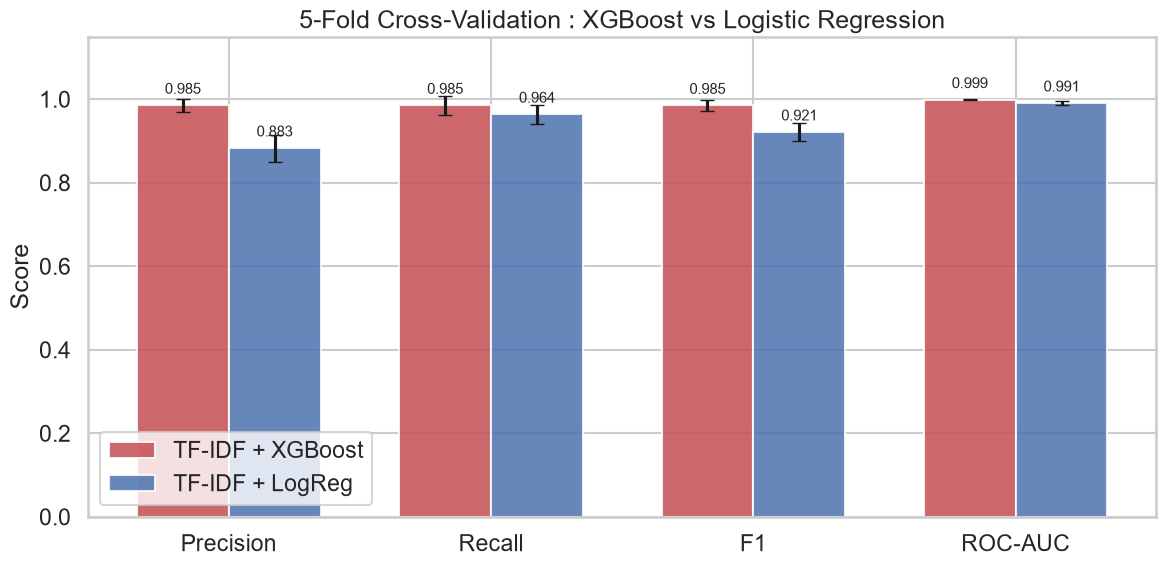

In [6]:
metrics_list = ["precision", "recall", "f1", "roc_auc"]
xgb_means  = [np.mean(results["xgboost"][m]) for m in metrics_list]
xgb_stds   = [np.std(results["xgboost"][m])  for m in metrics_list]
lr_means   = [np.mean(results["logreg"][m])  for m in metrics_list]
lr_stds    = [np.std(results["logreg"][m])   for m in metrics_list]

x = np.arange(len(metrics_list))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - w/2, xgb_means, w, yerr=xgb_stds, capsize=5,
               label="TF-IDF + XGBoost", color="#C44E52", alpha=0.85)
bars2 = ax.bar(x + w/2, lr_means,  w, yerr=lr_stds,  capsize=5,
               label="TF-IDF + LogReg", color="#4C72B0", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1", "ROC-AUC"])
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("5-Fold Cross-Validation : XGBoost vs Logistic Regression")
ax.legend()

# Value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

### Recall per fold:-

- This plot shows recall on each individual fold, not just the average.
- It answers the question:- are both models consistently good, or do they have good folds and bad folds?
- A flat line = very stable. A jagged line = performance depends heavily on which proposals end up in the test set.


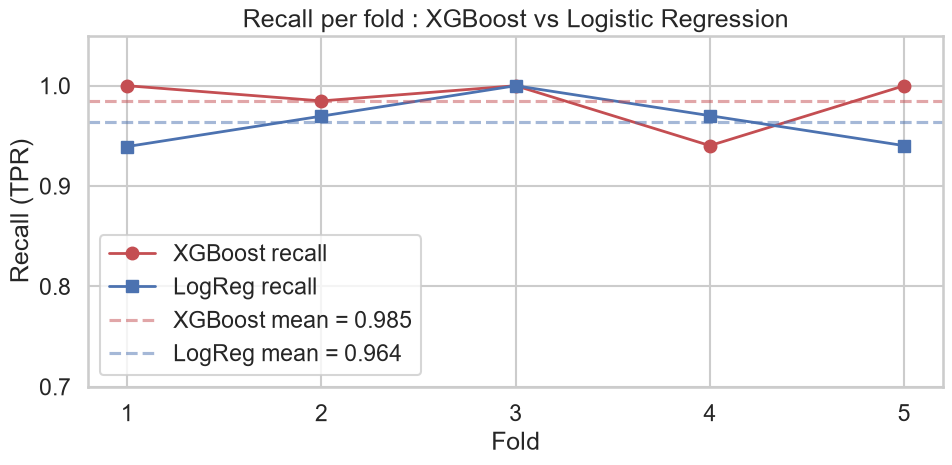

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
folds = list(range(1, 6))

ax.plot(folds, results["xgboost"]["recall"], marker="o", color="#C44E52",
        lw=2, label="XGBoost recall")
ax.plot(folds, results["logreg"]["recall"], marker="s", color="#4C72B0",
        lw=2, label="LogReg recall")

ax.axhline(np.mean(results["xgboost"]["recall"]), ls="--", color="#C44E52",
           alpha=0.5, label=f"XGBoost mean = {np.mean(results['xgboost']['recall']):.3f}")
ax.axhline(np.mean(results["logreg"]["recall"]), ls="--", color="#4C72B0",
           alpha=0.5, label=f"LogReg mean = {np.mean(results['logreg']['recall']):.3f}")

ax.set_xlabel("Fold")
ax.set_ylabel("Recall (TPR)")
ax.set_xticks(folds)
ax.set_ylim(0.7, 1.05)
ax.set_title("Recall per fold : XGBoost vs Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

### Which model wins and why?

- The most important metric for this project is **Recall**.
- A missed violation (False Negative) is more dangerous than a false alarm (False Positive).
- Recall directly measures how many real violations we caught.
- We also look at **F1** as a secondary metric, and **Std** as a stability check.


In [8]:
xgb_recall_mean = np.mean(results["xgboost"]["recall"])
lr_recall_mean  = np.mean(results["logreg"]["recall"])
xgb_recall_std  = np.std(results["xgboost"]["recall"])
lr_recall_std   = np.std(results["logreg"]["recall"])

xgb_f1_mean = np.mean(results["xgboost"]["f1"])
lr_f1_mean  = np.mean(results["logreg"]["f1"])

print("RECALL COMPARISON")
print("\n")
print(f"XGBoost  : mean = {xgb_recall_mean:.3f}  |  std = {xgb_recall_std:.3f}")
print(f"LogReg   : mean = {lr_recall_mean:.3f}  |  std = {lr_recall_std:.3f}")
print()

if xgb_recall_mean > lr_recall_mean:
    winner = "XGBoost"
    loser  = "LogReg"
    diff   = xgb_recall_mean - lr_recall_mean
elif lr_recall_mean > xgb_recall_mean:
    winner = "LogReg"
    loser  = "XGBoost"
    diff   = lr_recall_mean - xgb_recall_mean
else:
    winner = "Tie"
    diff   = 0.0

print(f"Winner on Recall : {winner}")
print(f"Difference       : {round(diff, 3)}")
print()
print("F1 COMPARISON")
print(f"XGBoost  : mean = {xgb_f1_mean:.3f}")
print(f"LogReg   : mean = {lr_f1_mean:.3f}")
print()

RECALL COMPARISON


XGBoost  : mean = 0.985  |  std = 0.023
LogReg   : mean = 0.964  |  std = 0.023

Winner on Recall : XGBoost
Difference       : 0.021

F1 COMPARISON
XGBoost  : mean = 0.985
LogReg   : mean = 0.921



### Cross-Validation Conclusion:-

- 5-Fold Stratified Cross-Validation was used so the comparison is not dependent on a single lucky or unlucky split.
- Both models were trained and tested on identical folds with identical TF-IDF features.
- The only difference between them is the classifier itself.
- Recall is the primary decision metric because missed violations are the most costly error in a compliance context.
- The model with higher mean recall and lower or comparable std is the stronger choice for the Compliance-Engine.
- This comparison feeds directly into Goal 3 where the winning model will be analysed with XAI (SHAP) and tested more rigorously.
